# MonteCarlo

In [2]:
import gymnasium as gym
import minigrid
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [3]:
# MiniGrid original actions
LEFT = 0
RIGHT = 1
FORWARD = 2

In [4]:
class SimpleMiniGridActions(gym.ActionWrapper):
    """
    Restrict MiniGrid actions to:
    0 = turn left
    1 = turn right
    2 = move forward
    """
    def __init__(self, env):
        super().__init__(env)
        self.action_space = gym.spaces.Discrete(3)

    def action(self, action):
        return int(action)

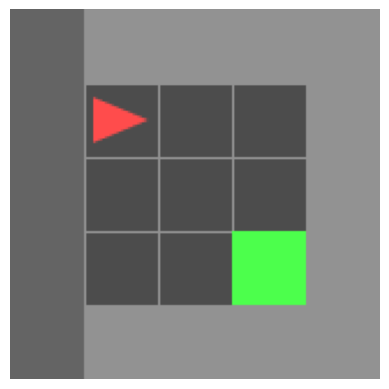

Observation keys: dict_keys(['image', 'direction', 'mission'])
Action space: Discrete(3)
Mission: get to the green goal square


In [7]:
env = gym.make("MiniGrid-Empty-5x5-v0", render_mode="rgb_array")
env = SimpleMiniGridActions(env)

obs, info = env.reset(seed=42)

plt.imshow(env.render())
plt.axis("off")
plt.show()

print("Observation keys:", obs.keys())
print("Action space:", env.action_space)
print("Mission:", obs["mission"])

In [13]:
class MCAgent:
    def __init__(
        self,
        env,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995
    ):
        self.env = env
        self.n_actions = env.action_space.n

        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.Q = defaultdict(lambda: np.zeros(self.n_actions))
        self.N = defaultdict(lambda: np.zeros(self.n_actions))

    def encode_state(self, obs):
        image = obs["image"].flatten()
        direction = obs["direction"]
        return tuple(image) + (int(direction),)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()

        return int(np.argmax(self.Q[state]))

    def generate_episode(self, max_steps=100):
        obs, info = self.env.reset()
        state = self.encode_state(obs)

        episode = []

        for _ in range(max_steps):
            action = self.choose_action(state)

            next_obs, reward, terminated, truncated, info = self.env.step(action)

            episode.append((state, action, reward))

            done = terminated or truncated
            if done:
                break

            state = self.encode_state(next_obs)

        return episode

    def update_from_episode(self, episode):
        G = 0
        returns = []

        for state, action, reward in reversed(episode):
            G = reward + self.gamma * G
            returns.insert(0, G)

        visited = set()

        for t, (state, action, reward) in enumerate(episode):
            if (state, action) in visited:
                continue

            visited.add((state, action))

            self.N[state][action] += 1
            alpha = 1.0 / self.N[state][action]

            self.Q[state][action] += alpha * (returns[t] - self.Q[state][action])

    def train(self, num_episodes=5000, max_steps=100):
        rewards_per_episode = []

        for episode_num in range(num_episodes):
            episode = self.generate_episode(max_steps=max_steps)
            self.update_from_episode(episode)

            total_reward = sum(reward for _, _, reward in episode)
            rewards_per_episode.append(total_reward)

            self.epsilon = max(
                self.epsilon_min,
                self.epsilon * self.epsilon_decay
            )

            if (episode_num + 1) % 500 == 0:
                avg_reward = np.mean(rewards_per_episode[-500:])
                print(
                    f"Episode {episode_num + 1}, "
                    f"Average reward: {avg_reward:.3f}, "
                    f"Epsilon: {self.epsilon:.3f}"
                )

        return rewards_per_episode

    def act_greedy(self, obs):
        state = self.encode_state(obs)
        return int(np.argmax(self.Q[state]))

In [14]:
agent = MCAgent(env)

rewards = agent.train(num_episodes=5000, max_steps=100)

Episode 500, Average reward: 0.879, Epsilon: 0.082
Episode 1000, Average reward: 0.951, Epsilon: 0.050
Episode 1500, Average reward: 0.951, Epsilon: 0.050
Episode 2000, Average reward: 0.952, Epsilon: 0.050
Episode 2500, Average reward: 0.952, Epsilon: 0.050
Episode 3000, Average reward: 0.952, Epsilon: 0.050
Episode 3500, Average reward: 0.952, Epsilon: 0.050
Episode 4000, Average reward: 0.951, Epsilon: 0.050
Episode 4500, Average reward: 0.952, Epsilon: 0.050
Episode 5000, Average reward: 0.952, Epsilon: 0.050


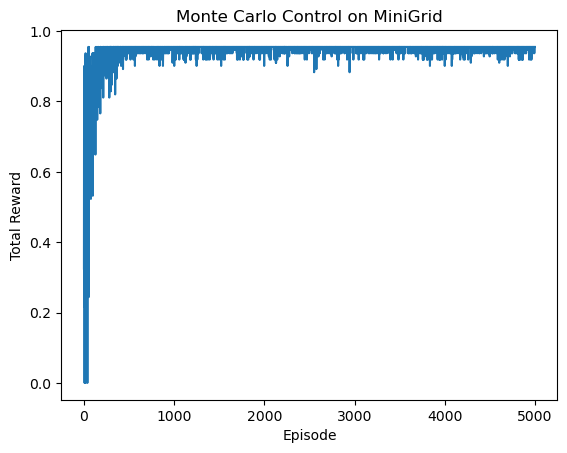

In [15]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Monte Carlo Control on MiniGrid")
plt.show()

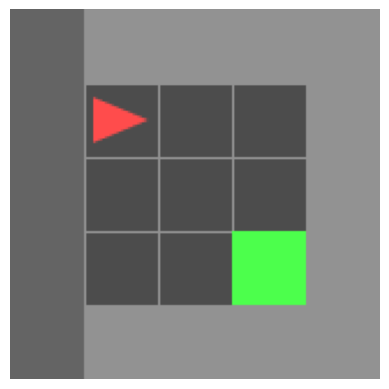

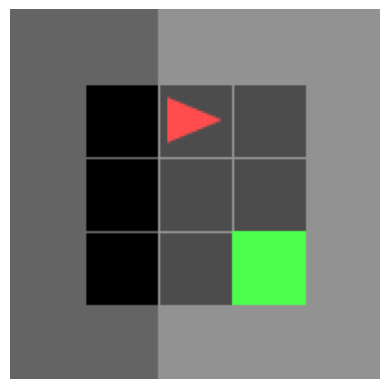

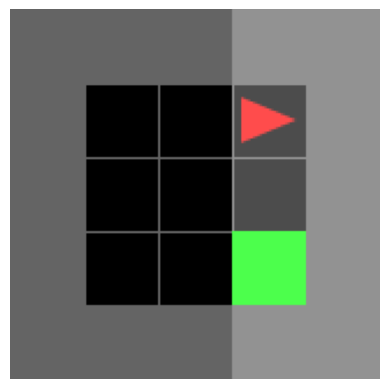

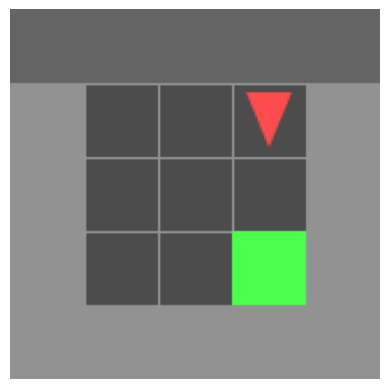

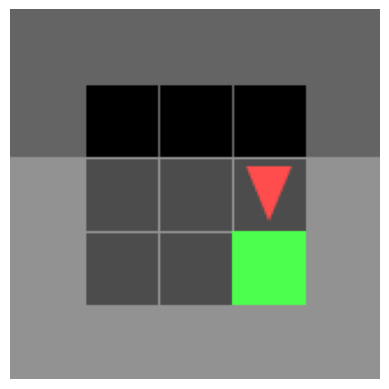

Finished: True
Total reward: 0.955


In [17]:
obs, info = env.reset(seed=123)

done = False
total_reward = 0

for step in range(50):
    plt.imshow(env.render())
    plt.axis("off")
    plt.show()

    action = agent.act_greedy(obs)

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    done = terminated or truncated

    if done:
        break

print("Finished:", done)
print("Total reward:", total_reward)